# Markov Chains (In-Class Exercise)

**Scenario:** Consider Earth in a *parallel* universe, affectionately named Planet Terror™ by the inhabitants, where weather forecasting works a little differently than it does on our Earth.

Each day on Planet Terror™, a planetary weather service reports a 5-day forecast with the probabilities that each day of the five days will be in one of four possible states:

| Symbol | State |
|--------|-------|
| R | Rainy |
| C | Cloudy |
| S | Sunny |
| G | Giant Meteor |

Your team has been hired to develop a software system to do this. As a first step, your team has put together a **Markov chain** that is a first approximation of the weather on Planet Terror™.

This is depicted below as a state-transition graph.

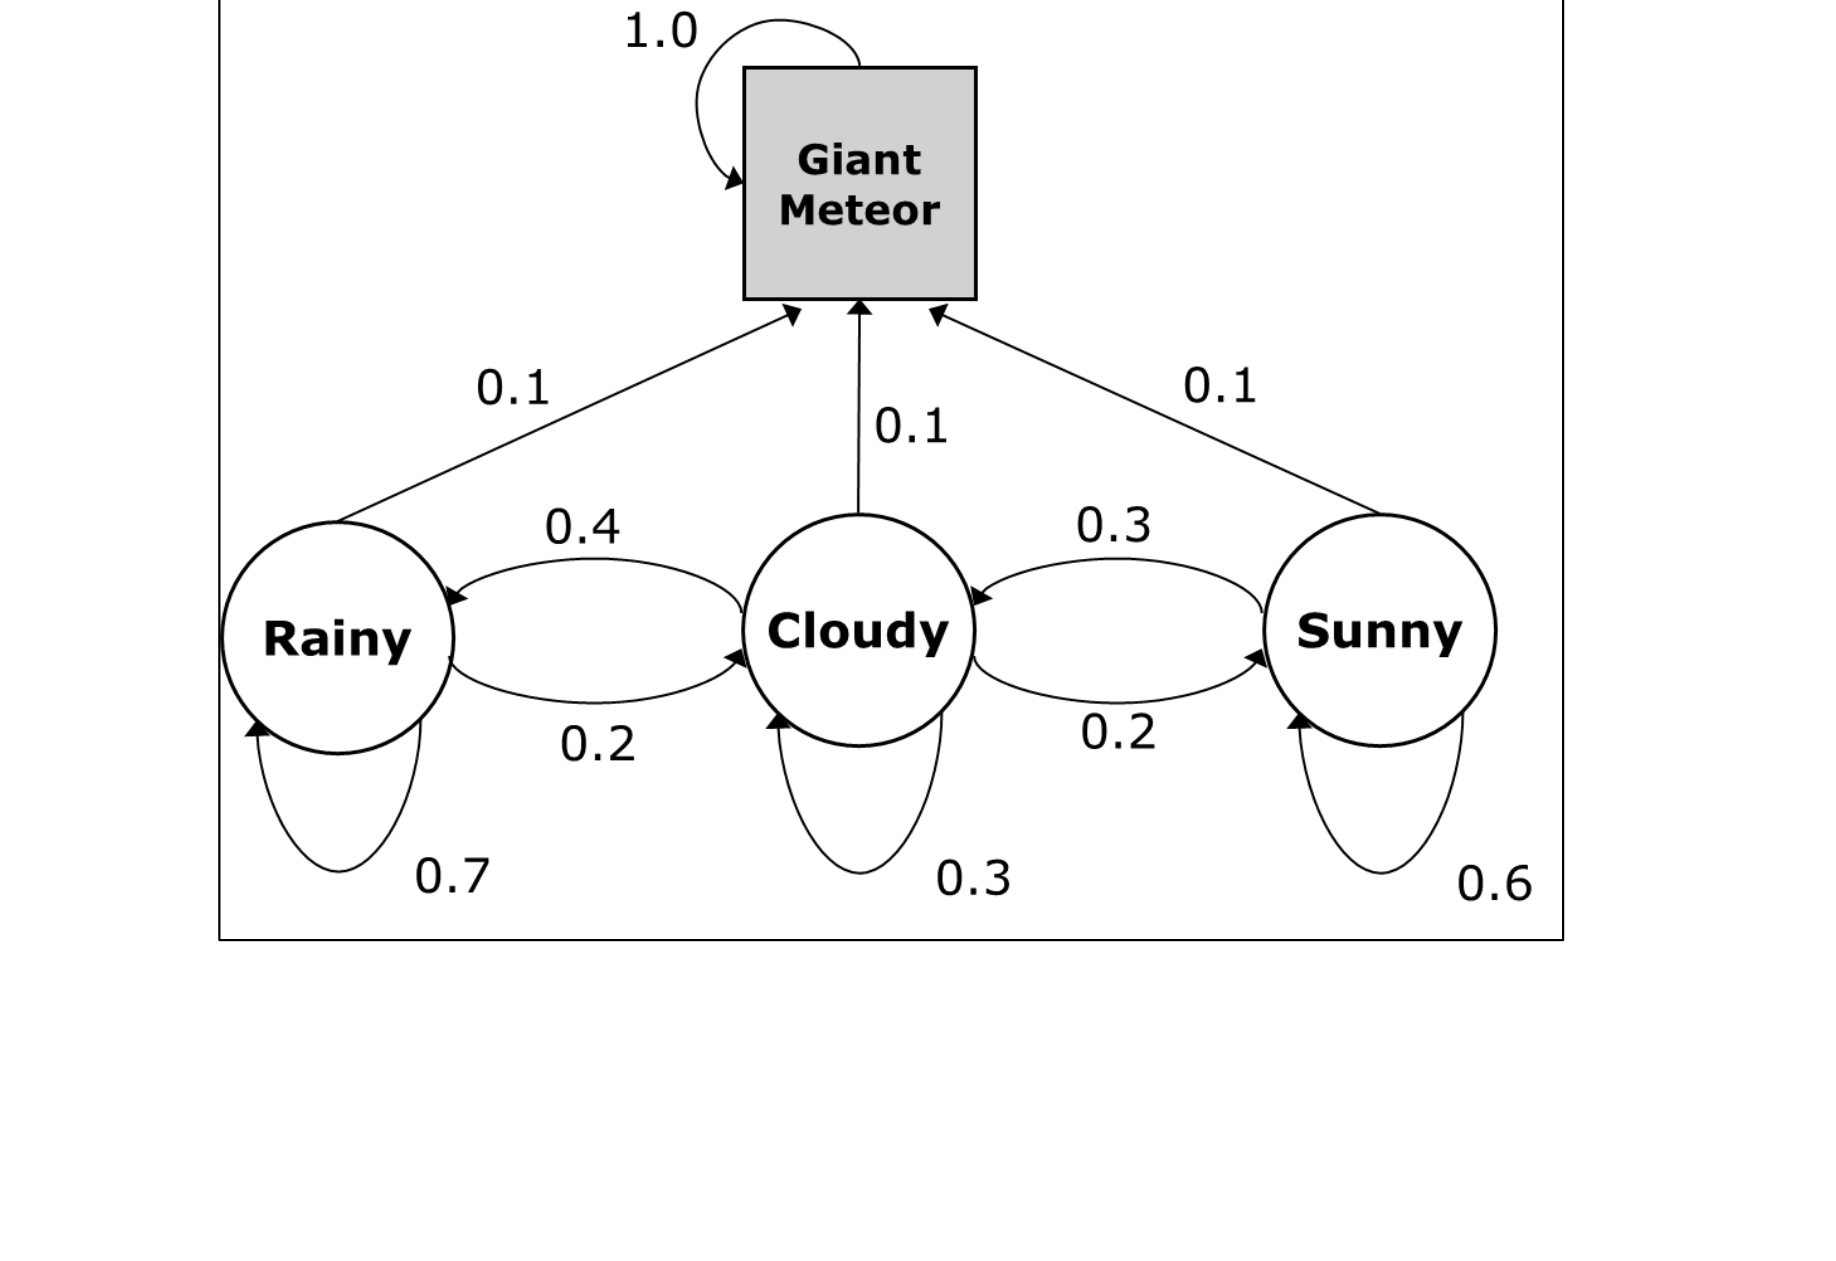

In [1]:
from IPython.display import Image
Image("figures/markov_chain.png", width=800)

---
## Exercise 1

**Question 1.1:** What is the **set of Markov states** for this Markov chain?

$$S = \{\text{Cloudy},\ \text{Giant Meteor},\ \text{Rainy},\ \text{Sunny}\}$$

**Question 1.2:** Write the **transition function** $p(S_{t+1} = s' \mid S_t = s)$ for this Markov chain as a transition matrix. (Rows and columns ordered alphabetically.)

In [2]:
import numpy as np
import pandas as pd

states = ["Cloudy", "Giant Meteor", "Rainy", "Sunny"]

# Transition Matrix (T)
# T[i, j] = P(next state = s_j | current state = s_i)
T = np.array([
    #  C     G     R     S
    [0.3,  0.1,  0.4,  0.2],   # Cloudy
    [0.0,  1.0,  0.0,  0.0],   # Giant Meteor
    [0.2,  0.1,  0.7,  0.0],   # Rainy
    [0.3,  0.1,  0.0,  0.6],   # Sunny
])

df = pd.DataFrame(T, index=states, columns=states)
df

,Cloudy,Giant Meteor,Rainy,Sunny
Cloudy,0.3,0.1,0.4,0.2
Giant Meteor,0.0,1.0,0.0,0.0
Rainy,0.2,0.1,0.7,0.0
Sunny,0.3,0.1,0.0,0.6


Each row sums to 1.0 (valid probability distribution over next states).
**Giant Meteor** is an *terminal state*: once reached, the system stays there with probability 1.

---
## Exercise 2

**Question 2.1:** What is the probability of **tomorrow** being Cloudy given that **today** is Sunny?

In [3]:
# State vector: today = Sunny  [Cloudy, Giant Meteor, Rainy, Sunny]
s_sunny = np.array([0, 0, 0, 1])

dist_tomorrow = s_sunny @ T

print("Distribution over tomorrow's states:")
for state, prob in zip(states, dist_tomorrow):
    print(f"  {state:15s}: {prob:.4f}")

print(f"\nP(tomorrow = Cloudy | today = Sunny) = {dist_tomorrow[states.index('Cloudy')]:.4f}")

Distribution over tomorrow's states:
  Cloudy         : 0.3000
  Giant Meteor   : 0.1000
  Rainy          : 0.0000
  Sunny          : 0.6000

P(tomorrow = Cloudy | today = Sunny) = 0.3000


In [4]:
# Or we could have read this directly from the transition matrix T
T[states.index('Sunny'), states.index('Cloudy')]

np.float64(0.3)

**Question 2.2:** What is the probability that the **day after tomorrow** is Sunny given that **today** is Rainy?

In [5]:
# State vector: today = Rainy  [Cloudy, Giant Meteor, Rainy, Sunny]
s_rainy = np.array([0, 0, 1, 0])

# Two-step prediction: s @ T^2
dist_day2 = s_rainy @ T @ T

print("Distribution over states in 2 days:")
for state, prob in zip(states, dist_day2):
    print(f"  {state:15s}: {prob:.4f}")

print(f"\nP(day after tomorrow = Sunny | today = Rainy) = {dist_day2[states.index('Sunny')]:.4f}")

Distribution over states in 2 days:
  Cloudy         : 0.2000
  Giant Meteor   : 0.1900
  Rainy          : 0.5700
  Sunny          : 0.0400

P(day after tomorrow = Sunny | today = Rainy) = 0.0400


**Question 2.3:** Assuming today is Sunny, what is the probability that a Giant Meteor will occur within the **next 5 days**?

In [6]:
# Because Giant Meteor is a terminal state, once it occurs the system stays there.
# Therefore: P(Giant Meteor within next 5 days) = P(in state Giant Meteor on day 5)
#
# Five-step prediction: s @ T^5

s_sunny = np.array([0, 0, 0, 1])
T5 = np.linalg.matrix_power(T, 5)

dist_day5 = s_sunny @ T5

print("Distribution over states in 5 days (starting from Sunny):")
for state, prob in zip(states, dist_day5):
    print(f"  {state:15s}: {prob:.4f}")

print(f"\nP(Giant Meteor within next 5 days | today = Sunny) = {dist_day5[states.index('Giant Meteor')]:.4f}")

Distribution over states in 5 days (starting from Sunny):
  Cloudy         : 0.1741
  Giant Meteor   : 0.4095
  Rainy          : 0.2386
  Sunny          : 0.1778

P(Giant Meteor within next 5 days | today = Sunny) = 0.4095


---
## P(Giant Meteor) Over Time

Since Giant Meteor is a terminal (absorbing) state, its probability monotonically increases and approaches 1.0 as $t \to \infty$. 

The plot below shows $P(S_t = \text{Giant Meteor})$ as a function of time step $t$ for each possible non-meteor starting state.

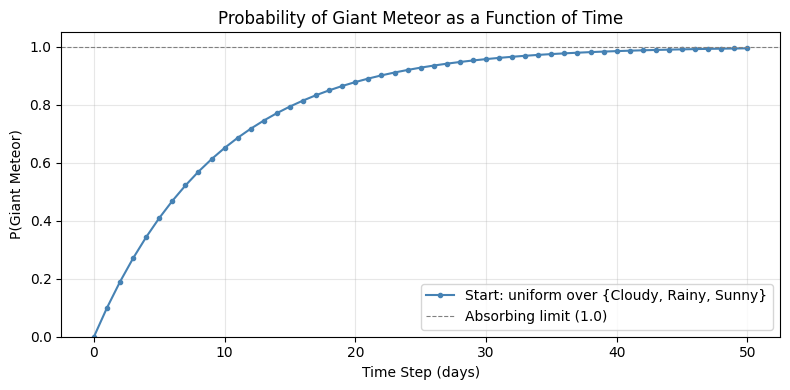

In [7]:
import matplotlib.pyplot as plt

G_idx = states.index("Giant Meteor")
max_steps = 50
steps = range(0, max_steps + 1)

# Uniform distribution over non-meteor starting states
s0 = np.array([1/3, 0, 1/3, 1/3])  # [Cloudy, Giant Meteor, Rainy, Sunny]

probs = [(s0 @ np.linalg.matrix_power(T, k))[G_idx] for k in steps]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps, probs, marker="o", markersize=3, color="steelblue",
        label="Start: uniform over {Cloudy, Rainy, Sunny}")
ax.set_xlabel("Time Step (days)")
ax.set_ylabel("P(Giant Meteor)")
ax.set_title("Probability of Giant Meteor as a Function of Time")
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Absorbing limit (1.0)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5-Day Weather Forecast

In [8]:
from IPython.display import HTML, display
from datetime import datetime, timedelta

# ── Configuration ─────────────────────────────────────────────────────────────
initial_state = "Sunny"   # Change to: "Cloudy", "Rainy", or "Sunny"
# ──────────────────────────────────────────────────────────────────────────────

# Build one-hot starting vector
s0 = np.zeros(len(states))
s0[states.index(initial_state)] = 1.0

# Per-state visual style
state_style = {
    "Sunny":        {"bg": "#FFF8DC", "border": "#F0B400", "icon": "☀️",  "label_color": "#7A5500"},
    "Cloudy":       {"bg": "#E8EFF5", "border": "#7FA8C9", "icon": "☁️",  "label_color": "#2C4A63"},
    "Rainy":        {"bg": "#D6E8F5", "border": "#2E6DA4", "icon": "🌧️", "label_color": "#1A3D5C"},
    "Giant Meteor": {"bg": "#FDE8E8", "border": "#C0392B", "icon": "☄️", "label_color": "#7B1A1A"},
}

# Day labels starting from tomorrow
today = datetime.today()
day_names   = [(today + timedelta(days=k)).strftime("%A")   for k in range(1, 6)]
date_labels = [(today + timedelta(days=k)).strftime("%b %-d") for k in range(1, 6)]

# Compute 5-day forecast
forecast = []
for k in range(1, 6):
    dist = s0 @ np.linalg.matrix_power(T, k)
    dom_idx   = int(np.argmax(dist))
    dom_state = states[dom_idx]
    dom_prob  = dist[dom_idx]
    forecast.append({
        "day":      day_names[k - 1],
        "date":     date_labels[k - 1],
        "state":    dom_state,
        "prob":     dom_prob,
        "rain_pct": dist[states.index("Rainy")] * 100,
    })

# Build card HTML
cards_html = ""
for f in forecast:
    s = state_style[f["state"]]
    precip = f'<div class="precip">🌂 {f["rain_pct"]:.0f}% chance of precip.</div>'

    cards_html += f"""
      <div class="card" style="background:{s['bg']};border:2px solid {s['border']};">
        <div class="day-name">{f['day']}</div>
        <div class="date-label">{f['date']}</div>
        <div class="icon">{s['icon']}</div>
        <div class="state-label" style="color:{s['label_color']};">{f['state']}</div>
        <div class="prob-label">{f['prob'] * 100:.0f}%</div>
        {precip}
      </div>"""

html = f"""
<style>
  .wx-wrap {{
    font-family: 'Segoe UI', Arial, sans-serif;
    background: linear-gradient(160deg, #0d1b3e 0%, #1e3d72 60%, #1a5276 100%);
    border-radius: 14px;
    padding: 20px 20px 18px;
    max-width: 680px;
    color: #fff;
    box-shadow: 0 4px 18px rgba(0,0,0,0.4);
  }}
  .wx-header {{ margin-bottom: 4px; }}
  .wx-station {{
    font-size: 1.25em;
    font-weight: 700;
    letter-spacing: 1.5px;
    text-transform: uppercase;
  }}
  .wx-subtitle {{
    font-size: 0.82em;
    opacity: 0.65;
    margin-bottom: 16px;
  }}
  .wx-cards {{
    display: flex;
    gap: 10px;
  }}
  .card {{
    flex: 1;
    border-radius: 10px;
    padding: 12px 6px 10px;
    text-align: center;
    box-shadow: 0 2px 6px rgba(0,0,0,0.15);
  }}
  .day-name   {{ font-weight: 700; font-size: 0.92em; color: #1a1a2e; }}
  .date-label {{ font-size: 0.72em; color: #555; margin-bottom: 6px; }}
  .icon       {{ font-size: 2.4em; line-height: 1.1; margin: 4px 0; }}
  .state-label {{ font-weight: 700; font-size: 0.82em; margin: 4px 0 2px; }}
  .prob-label  {{ font-size: 1.15em; font-weight: 800; color: #222; }}
  .precip      {{ font-size: 0.70em; color: #1a4f7a; margin-top: 5px; min-height: 1em; }}
  .wx-footer  {{ font-size: 0.70em; opacity: 0.5; margin-top: 12px; text-align: right; }}
</style>
<div class="wx-wrap">
  <div class="wx-header">
    <div class="wx-station">🌍 Planet Terror™ Weather</div>
    <div class="wx-subtitle">
      5-Day Forecast &nbsp;·&nbsp; Starting condition: <strong>{initial_state}</strong>
      &nbsp;·&nbsp; Powered by Markov Chain v1.0
    </div>
  </div>
  <div class="wx-cards">{cards_html}
  </div>
  <div class="wx-footer">Probabilities computed via T<sup>k</sup> matrix exponentiation</div>
</div>
"""

display(HTML(html))

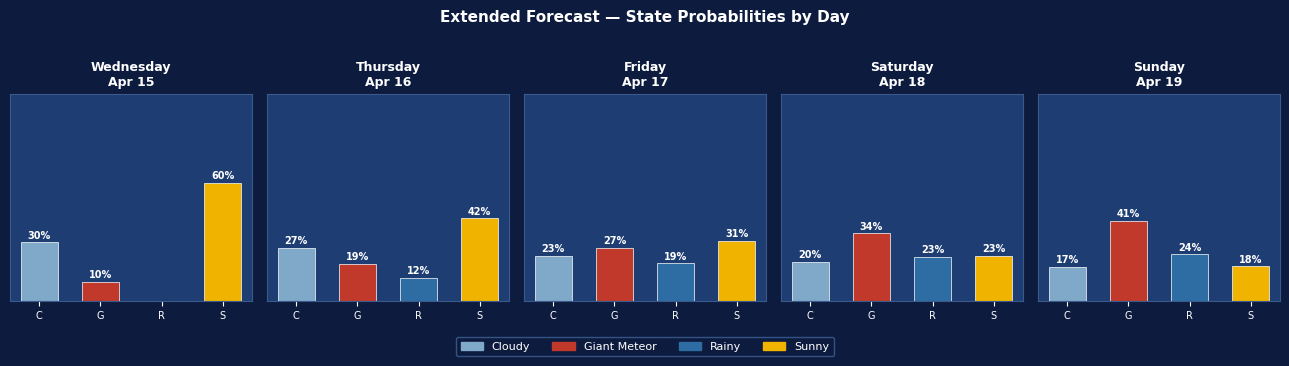

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

bar_colors = {
    "Cloudy":       "#7FA8C9",
    "Giant Meteor": "#C0392B",
    "Rainy":        "#2E6DA4",
    "Sunny":        "#F0B400",
}
short_labels = ["C", "G", "R", "S"]   # Cloudy, Giant Meteor, Rainy, Sunny

fig, axes = plt.subplots(1, 5, figsize=(13, 3.2), sharey=True)
fig.patch.set_facecolor("#0d1b3e")

for ax, f in zip(axes, forecast):
    day_dist = s0 @ np.linalg.matrix_power(T, forecast.index(f) + 1)
    probs_pct = day_dist * 100
    colors = [bar_colors[s] for s in states]

    bars = ax.bar(range(len(states)), probs_pct, color=colors,
                  edgecolor="white", linewidth=0.5, width=0.6)

    # Label bars with percentage
    for bar, pct in zip(bars, probs_pct):
        if pct >= 5:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f"{pct:.0f}%", ha="center", va="bottom", fontsize=7,
                    color="white", fontweight="bold")

    ax.set_title(f"{f['day']}\n{f['date']}", color="white", fontsize=9, fontweight="bold", pad=6)
    ax.set_ylim(0, 105)
    ax.set_facecolor("#1e3d72")
    ax.set_xticks(range(len(states)))
    ax.set_xticklabels(short_labels, color="white", fontsize=8)
    ax.tick_params(colors="white", labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor("#3a5a8a")
    ax.yaxis.set_visible(False)

# Shared legend
legend_patches = [mpatches.Patch(color=bar_colors[s], label=s) for s in states]
fig.legend(handles=legend_patches, loc="lower center", ncol=4,
           facecolor="#0d1b3e", edgecolor="#3a5a8a", labelcolor="white",
           fontsize=8, framealpha=0.9, bbox_to_anchor=(0.5, -0.08))

fig.suptitle("Extended Forecast — State Probabilities by Day",
             color="white", fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()